In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import nbinom, norm, fisk, geom, gamma, gompertz, invgauss

## Load in the observations

In [34]:
obs = np.load("patch_lengths.npy")

In [46]:
np.sort(obs[obs>16])

array([17., 17., 17., 17., 17., 17., 18., 18., 18., 18., 18., 19., 19.,
       19., 19., 19., 19., 20., 20., 20., 20., 20., 20., 21., 21., 22.,
       25., 26., 29., 32.])

## Empirical hazard (leaving rate over time in patch)

Discrete hazard h(t) = P(leave at t | still in patch at t) = count(T=t) / count(T≥t)

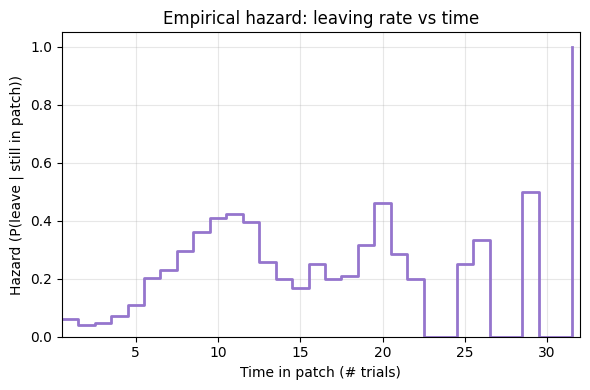

In [52]:
x = obs.astype(int)
t_max = int(x.max())
times = np.arange(1, t_max + 1)
at_risk = np.array([np.sum(x >= t) for t in times])
failures = np.array([np.sum(x == t) for t in times])
hazard = np.where(at_risk > 0, failures / at_risk, np.nan)

plt.figure(figsize=(6, 4))
plt.step(times - 0.5, hazard, where="post", color="#9575cd", linewidth=2)
plt.xlabel("Time in patch (# trials)")
plt.ylabel("Hazard (P(leave | still in patch))")
plt.title("Empirical hazard: leaving rate vs time")
plt.xlim(0.5, t_max)
plt.ylim(0, None)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
obs

array([ 3.,  6.,  4., ...,  8., 15., 10.], shape=(2015,))

todo - add repeated likelihood code to the class?

## The fitting class to reduce repeated code

In [20]:
class DistributionFitter:
    """
    Fits a distribution to our patch leaving times by finding the parameters of the distribution that minimizes the negative log-likelihood between the distribution and the observations.
    You pass in your nll function, init, bounds, and param_names.
    """

    def __init__(self, name, nll_func, init, param_names, bounds=None):
        """
        Parameters
        ----------
        name : str
            Label for this distribution (e.g. "weibull").

        nll_func : callable
            Negative log-likelihood: nll_func(params, x) -> scalar.
            params is a 1D array; x is the array of observations -> number of stays in each patch.

        init : array-like or callable
            Initial guess of the parameters

        param_names : list of str
            Names for each parameter (for the output params dict).

        bounds : list of (low, high) or None
            Bounds per parameter. Use None for unbounded. low/high can be None.

        """

        self.name = name
        self.nll_func = nll_func
        self.init = init
        self.param_names = param_names
        self.bounds = bounds

    def fit(self, x):
        """Fit to patch residency time observations. Returns (params, aic, bic)."""

        init = self.init
        result = minimize(
            self.nll_func, init, args=(x,), method="L-BFGS-B",
            bounds=self.bounds if self.bounds is not None else [(None, None)] * len(init), # if we dont pass bounds, just use None
        )

        k = len(init) # number of parameters
        N = len(x) # number of observations
        params = {name: round(v, 2) for name, v in zip(self.param_names, result.x)}
        aic = 2 * k + 2 * result.fun
        bic = k * np.log(N) + 2 * result.fun
        return params, aic, bic

    def fit_row(self, x):
        """Fit and return a row dict for appending to distributions_df."""
        params, aic, bic = self.fit(x)
        return {"distribution": self.name, "params": params, "aic": round(aic, 2), "bic": round(bic, 2)}

In [21]:
def fit_distributions(x, fitters):
    """
    Fit multiple distributions and return a DataFrame sorted by AIC.
    """
    rows = [f.fit_row(x) for f in fitters]
    df = pd.DataFrame(rows).sort_values(by="aic").reset_index(drop=True)
    return df

## Define the likelihoods of the distributions


- I am going to inflate x=1 in the likelihoods and see if it affects the MLE estimation
- Hopefully the ordering remains the same
- If it changes, I have no way of proving that x=1 is not being generated from a separate process than we are interested in, so I have no way of showing which version I care about 

In [22]:
def nll_discrete_lognormal(params, x):
    "Negative log likelihood of discrete lognormal distribution"

    # unpack parameters
    mu, sigma = params
    likelihood = np.zeros_like(x)

    # calculate likelihood of observations using discrete lognormal distribution
    # going to do different flow for x=1 to avoid runtime error from log(0)
    mask_1 = (x == 1)

    # first for x not = 1
    mask_not_1 = ~mask_1
    likelihood[mask_not_1] = norm.cdf(np.log(x[mask_not_1]), loc=mu, scale=sigma) - norm.cdf(np.log(x[mask_not_1]-1), loc=mu, scale=sigma)

    # for x = 1 the second term cancels out, and first term log(1) = 0
    likelihood[mask_1] = norm.cdf(0, loc=mu, scale=sigma)
    

    # prevent issues from log(0) due to python rounding down to 0
    likelihood = np.clip(likelihood, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihood))

    return nll


def nll_negative_binomial(params, x):
    "Negative log likelihood of negative binomial distribution"

    # unpack parameters
    r, p = params # r = number of failures, p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = nbinom.pmf(x-1, r, p)  # x-1 because x starts at 1, already discretised no p(x) - p(x-1) needed

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_geometric(params, x):
    "Negative log likelihood of the geometric distribution"

    # unpack parameters
    p = params #p = probability of success
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = geom.pmf(x, p) 

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_discrete_weibull(params, x):
    "Negative log likelihood of discrete weibull distribution"

    # unpack parameters
    q, beta = params
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = q ** ((x - 1) ** beta) - q ** (x ** beta)

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

def nll_gamma(params, x):
    "Negative log likelihood of the gamma distribution"

    # unpack parameters
    a, s = params # a = shape, s = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gamma.cdf(x, a, scale=s) - gamma.cdf(x-1, a, scale=s)  # now we need to discretise again

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_log_logistic(params, x):
    "Negative log likelihood of the discretised log-logistic distribution"

    # unpack parameters
    k, lambda_ = params # k = shape, lambda_ = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = fisk.cdf(x, k, scale=lambda_) - fisk.cdf(x-1, k, scale=lambda_)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_gompertz(params, x):
    "Negative log likelihood of the discretised gompertz distribution"

    # unpack parameters
    eta, beta = params # eta = shape, beta = scale
    likelihoods = np.zeros_like(x)
    
    # calculate likelihoods
    likelihoods = gompertz.cdf(x, eta, scale=beta) - gompertz.cdf(x-1, eta, scale=beta)  

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

## Run the full process and view results

In [25]:
fitters = [

    DistributionFitter("discrete lognormal", 
                        nll_discrete_lognormal, 
                        [1.8, 0.63],  # derived in different notebook
                        ["mu", "sigma"],
                       bounds=[(None, None), 
                               (None, None)]),

    DistributionFitter("discrete weibull", 
                        nll_discrete_weibull, 
                        [0.5, 1.0], 
                        ["q", "beta"],
                       bounds=[(1e-9, 1 - 1e-9), 
                               (1e-9, None)]),

    DistributionFitter("negative binomial", 
                        nll_negative_binomial, 
                        [1.0, 0.5], 
                        ["r", "p"],
                       bounds=[(1e-9, None), 
                               (1e-9, 1 - 1e-9)]),
                            
    DistributionFitter("geometric", 
                        nll_geometric, 
                        [0.5], 
                        ["p"],
                       bounds=[(1e-9, 1 - 1e-9)]),

    DistributionFitter("gamma", 
                        nll_gamma, 
                        [0.9, 1.0], 
                        ["a", "s"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

    DistributionFitter("discretelog-logistic", 
                        nll_log_logistic, 
                        [0.9, 1.0], 
                        ["k", "lambda_"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

    DistributionFitter("discrete gompertz", 
                        nll_gompertz, 
                        [0.9, 1.0], 
                        ["eta", "beta"],
                       bounds=[(1e-9, None), 
                               (1e-9, None)]),

]

# fit to the obs and create the fitting dataframe
df = fit_distributions(obs, fitters)
df

,distribution,params,aic,bic
0,discrete weibull,"{'q': 0.98, 'beta': 1.95}",10616.23,10627.45
1,negative binomial,"{'r': 5.88, 'p': 0.49}",10621.72,10632.93
2,gamma,"{'a': 2.82, 's': 2.33}",10795.95,10807.17
3,discretelog-logistic,"{'k': 2.83, 'lambda_': 6.08}",11009.73,11020.94
4,discrete lognormal,"{'mu': 1.71, 'sigma': 0.69}",11282.51,11293.73
5,geometric,{'p': 0.14},11616.75,11622.36
6,discrete gompertz,"{'eta': 0.41, 'beta': 6.2}",12123.02,12134.24


## Change the distributions to also have x=1 inflation

In [38]:
def nll_discrete_lognormal_inflated(params, x):
    "Negative log likelihood of discrete lognormal distribution, extra probability injected at x=1"

    # unpack parameters
    mu, sigma, pi = params
    likelihood = np.zeros_like(x, dtype=np.float64)

    # calculate likelihood of observations using discrete lognormal distribution
    # going to do different flow for x=1 to avoid runtime error from log(0)
    mask_1 = (x == 1)

    # first for x not = 1
    mask_not_1 = ~mask_1
    likelihood[mask_not_1] = (1-pi) * (norm.cdf(np.log(x[mask_not_1]), loc=mu, scale=sigma) - norm.cdf(np.log(x[mask_not_1]-1), loc=mu, scale=sigma))

    # for x = 1 the second term cancels out, and first term log(1) = 0
    likelihood[mask_1] = pi + (1-pi) * norm.cdf(0, loc=mu, scale=sigma)
    

    # prevent issues from log(0) due to python rounding down to 0
    likelihood = np.clip(likelihood, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihood))

    return nll


def nll_discrete_inverse_gaussian_inflated(params, x):
    "Negative log likelihood of negative binomial distribution, extra probability injected at x=1"

    # unpack parameters
    mu, scale, pi = params 
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * invgauss.cdf(1, mu=mu, scale=scale)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (invgauss.cdf(x[mask_not_1], mu=mu, scale=scale) - invgauss.cdf(x[mask_not_1] - 1, mu=mu, scale=scale))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_geometric_inflated(params, x):
    "Negative log likelihood of the geometric distribution, extra probability injected at x=1"

    # unpack parameters
    p, pi = params #p = probability of success
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * geom.pmf(1, p)

    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * geom.pmf(x[mask_not_1], p)

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_discrete_weibull_inflated(params, x):
    "Negative log likelihood of discrete weibull distribution, extra probability injected at x=1"

    # unpack parameters
    q, beta, pi = params
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * (q ** ((1 - 1) ** beta) - q ** (1 ** beta))

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (q ** ((x[mask_not_1] - 1) ** beta) - q ** (x[mask_not_1] ** beta))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

def nll_gamma_inflated(params, x):
    "Negative log likelihood of the gamma distribution, extra probability injected at x=1"

    # unpack parameters
    a, s, pi = params # a = shape, s = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * gamma.cdf(1, a, scale=s)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (gamma.cdf(x[mask_not_1], a, scale=s) - gamma.cdf(x[mask_not_1]-1, a, scale=s))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_log_logistic_inflated(params, x):
    "Negative log likelihood of the discretised log-logistic distribution"

    # unpack parameters
    k, lambda_, pi = params # k = shape, lambda_ = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * fisk.cdf(1, k, scale=lambda_)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (fisk.cdf(x[mask_not_1], k, scale=lambda_) - fisk.cdf(x[mask_not_1]-1, k, scale=lambda_))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll


def nll_gompertz_inflated(params, x):
    "Negative log likelihood of the discretised gompertz distribution, extra probability injected at x=1"

    # unpack parameters
    eta, beta, pi = params # eta = shape, beta = scale
    likelihoods = np.zeros_like(x, dtype=np.float64)
    
    # calculate likelihoods (x=1)
    mask_1 = (x == 1)
    likelihoods[mask_1] = pi + (1-pi) * gompertz.cdf(1, eta, scale=beta)

    # calculate likelihoods (x>1)
    mask_not_1 = ~mask_1
    likelihoods[mask_not_1] = (1-pi) * (gompertz.cdf(x[mask_not_1], eta, scale=beta) - gompertz.cdf(x[mask_not_1]-1, eta, scale=beta))

    # prevent issues from log(0) due to python rounding down to 0
    likelihoods = np.clip(likelihoods, min=1e-300)

    # calculate negative log likelihood 
    nll = -np.sum(np.log(likelihoods))

    return nll

## Fit

In [39]:
fitters = [

    DistributionFitter("discrete lognormal_inf", 
                        nll_discrete_lognormal_inflated, 
                        [1.8, 0.63, 0.5],  # derived in different notebook
                        ["mu", "sigma", "pi"],
                       bounds=[(None, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete weibull_inf", 
                        nll_discrete_weibull_inflated, 
                        [0.5, 1.0, 0.5], 
                        ["q", "beta", "pi"],
                       bounds=[(1e-9, 1 - 1e-9), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete inverse gaussian inf", 
                        nll_discrete_inverse_gaussian_inflated, 
                        [0.4, 0.5, 0.5], 
                        ["r", "p", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),
                            
    DistributionFitter("geometric_inf", 
                        nll_geometric_inflated, 
                        [0.5, 0.5], 
                        ["p", "pi"],
                       bounds=[(1e-9, 1 - 1e-9),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("gamma_inf", 
                        nll_gamma_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["a", "s", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discretelog-logistic_inf", 
                        nll_log_logistic_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["k", "lambda_", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

    DistributionFitter("discrete gompertz_inf", 
                        nll_gompertz_inflated, 
                        [0.9, 1.0, 0.5], 
                        ["eta", "beta", "pi"],
                       bounds=[(1e-9, None), 
                               (1e-9, None),
                               (1e-9, 1-1e-9)]),

]

# fit to the obs and create the fitting dataframe
df = fit_distributions(obs, fitters)
df

,distribution,params,aic,bic
0,gamma_inf,"{'a': 4.8, 's': 1.45, 'pi': 0.06}",10409.44,10426.26
1,discrete weibull_inf,"{'q': 0.99, 'beta': 2.25, 'pi': 0.05}",10451.30,10468.12
2,discretelog-logistic_inf,"{'k': 3.81, 'lambda_': 6.52, 'pi': 0.06}",10454.56,10471.39
3,discrete lognormal_inf,"{'mu': 1.84, 'sigma': 0.48, 'pi': 0.06}",10553.08,10569.91
4,discrete inverse gaussian inf,"{'r': 0.26, 'p': 26.65, 'pi': 0.06}",10612.63,10629.46
5,geometric_inf,"{'p': 0.14, 'pi': 0.0}",11618.75,11629.97
6,discrete gompertz_inf,"{'eta': 0.42, 'beta': 6.3, 'pi': 0.0}",12124.70,12141.52
